Import Libraries

In [1]:
import pandas as pd


In [2]:
import numpy as np


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns



Load Dataset

In [4]:
df = pd.read_csv("/content/sales_dataset csv.csv")

In [5]:
df.head()

,Order Date,Region,Sales,Year,Month,Month-Year,Profit
0,08-11-2017,South,261.9600,2017,11,Nov-17,52.3920
1,08-11-2017,South,731.9400,2017,11,Nov-17,146.3880
2,12-06-2017,West,14.6200,2017,6,Jun-17,2.9240
3,11-10-2016,South,957.5775,2016,10,Oct-16,191.5155
4,11-10-2016,South,22.3680,2016,10,Oct-16,4.4736


Explore Dataset

In [6]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order Date  9800 non-null   object 
 1   Region      9800 non-null   object 
 2   Sales       9800 non-null   float64
 3   Year        9800 non-null   int64  
 4   Month       9800 non-null   int64  
 5   Month-Year  9800 non-null   object 
 6   Profit      9800 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 536.1+ KB


Checking Missing Values

In [7]:
print("\nMissing values in each column:")
print(df.isnull().sum())



Missing values in each column:
Order Date    0
Region        0
Sales         0
Year          0
Month         0
Month-Year    0
Profit        0
dtype: int64


Statistical Summary of Dataset

In [8]:
print("\nBasic statistics:")
display(df.describe())



Basic statistics:


,Sales,Year,Month,Profit
count,9800.000000,9800.000000,9800.000000,9800.000000
mean,230.769059,2016.724184,7.818469,46.153812
std,626.651875,1.123984,3.281905,125.330375
min,0.444000,2015.000000,1.000000,0.088800
25%,17.248000,2016.000000,5.000000,3.449600
50%,54.490000,2017.000000,9.000000,10.898000
75%,210.605000,2018.000000,11.000000,42.121000
max,22638.480000,2018.000000,12.000000,4527.696000


Clean Dataset

In [9]:
df.fillna(0, inplace=True)          # Fill missing numeric values

df.drop_duplicates(inplace=True)    # Remove duplicate rows



Profit Calculation (If Missing)

In [10]:
if 'Profit' not in df.columns:
    if 'Sales' in df.columns and 'Cost' in df.columns:
        df['Profit'] = df['Sales'] - df['Cost']
    else:
        print("Profit cannot be calculated: Sales or Cost column missing")


Calculate Key Metrics

In [11]:
# Clean column names
df.columns = df.columns.str.strip()

# Convert to numeric
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')

# Metrics
total_sales = df['Sales'].sum()
average_sales = df['Sales'].mean()
min_sales = df['Sales'].min()
max_sales = df['Sales'].max()
std_sales = df['Sales'].std()

total_profit = df['Profit'].sum()

if pd.notnull(total_sales) and total_sales != 0:
    profit_margin = (total_profit / total_sales) * 100
else:
    profit_margin = 0
print("Total Sales:", total_sales)
print("Average Sales:", average_sales)
print("Min Sales:", min_sales)
print("Max Sales:", max_sales)
print("Standard Deviation:", std_sales)
print("Total Profit:", total_profit)
print("Profit Margin:", profit_margin)

Total Sales: 2261152.7827000003
Average Sales: 230.87122551562183
Min Sales: 0.444
Max Sales: 22638.48
Standard Deviation: 626.8255665742824
Total Profit: 452230.55654
Profit Margin: 20.0


Statistical Measures

In [12]:
# Statistical Measures for Sales

sales_mean = df['Sales'].mean()
sales_median = df['Sales'].median()
sales_mode = df['Sales'].mode()[0]
sales_variance = df['Sales'].var()

print("Sales Statistics:")
print("Mean:", sales_mean)
print("Median:", sales_median)
print("Mode:", sales_mode)
print("Variance:", sales_variance)

Sales Statistics:
Mean: 230.87122551562183
Median: 54.593999999999994
Mode: 12.96
Variance: 392910.29091117013


Monthly Analysis

In [13]:
if 'Month' in df.columns:
    monthly_sales = df.groupby('Month')['Sales'].sum()
    monthly_profit = df.groupby('Month')['Profit'].sum()
    monthly_growth = monthly_sales.pct_change() * 100

    print("\nMonthly Sales:")
    display(monthly_sales)
    print("\nMonthly Profit:")
    display(monthly_profit)
    print("\nMonthly Growth (%):")
    display(monthly_growth)



Monthly Sales:


,Sales
Month,
1,94291.6296
2,59371.1154
3,197573.5872
4,135978.6686
5,154086.7237
6,145837.5233
7,145505.3610
8,157315.9270
9,300054.0717



Monthly Profit:


,Profit
Month,
1,18858.32592
2,11874.22308
3,39514.71744
4,27195.73372
5,30817.34474
6,29167.50466
7,29101.07220
8,31463.18540
9,60010.81434



Monthly Growth (%):


,Sales
Month,
1,NaN
2,-37.034586
3,232.777287
4,-31.175685
5,13.316835
6,-5.353609
7,-0.227762
8,8.116928
9,90.733435


Regional / Product Analysis

In [14]:
if 'Region' in df.columns:
    region_profit = df.groupby('Region')['Profit'].sum()
    print("\nProfit by Region:")
    display(region_profit)




Profit by Region:


,Profit
Region,
Central,98529.38264
East,133847.47080
South,77824.71420
West,142028.98890


Loss Analysis

In [15]:
if 'Region' in df.columns:
    loss_data = df[df['Profit'] < 0]   # filter only loss rows
    region_loss = loss_data.groupby('Region')['Profit'].sum()

    print("\nLoss by Region:")
    display(region_loss)


Loss by Region:


,Profit
Region,


Monthly Visualization

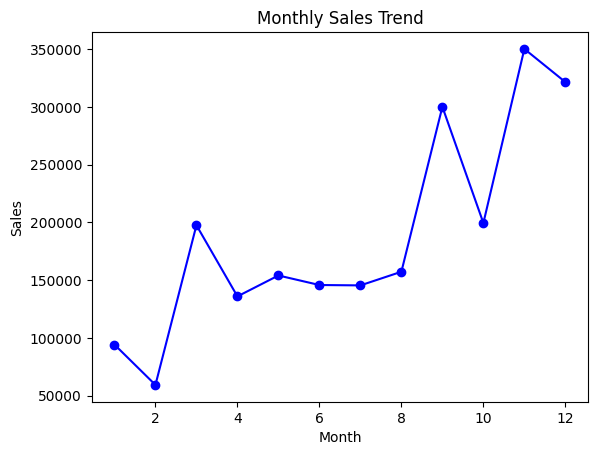

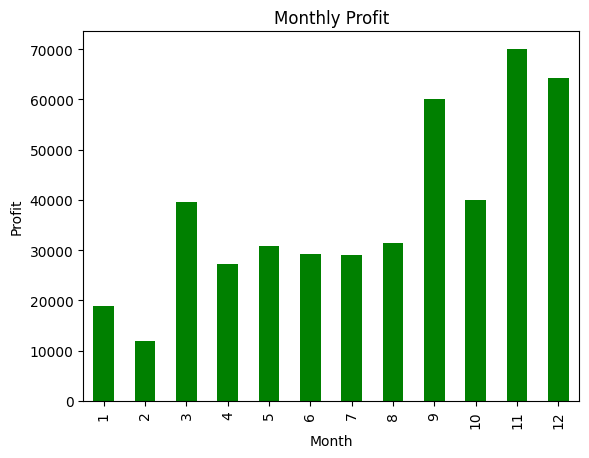

In [16]:
if 'Month' in df.columns:
    monthly_sales.plot(kind='line', marker='o', color='blue', title='Monthly Sales Trend')
    plt.xlabel('Month')
    plt.ylabel('Sales')
    plt.show()

    monthly_profit.plot(kind='bar', color='green', title='Monthly Profit')
    plt.xlabel('Month')
    plt.ylabel('Profit')
    plt.show()

Year Wise analysis


Year-wise Sales:
Year
2015    479551.8761
2016    459431.0774
2017    600137.2500
2018    722032.5792
Name: Sales, dtype: float64

Year-wise Profit:
Year
2015     95910.37522
2016     91886.21548
2017    120027.45000
2018    144406.51584
Name: Profit, dtype: float64


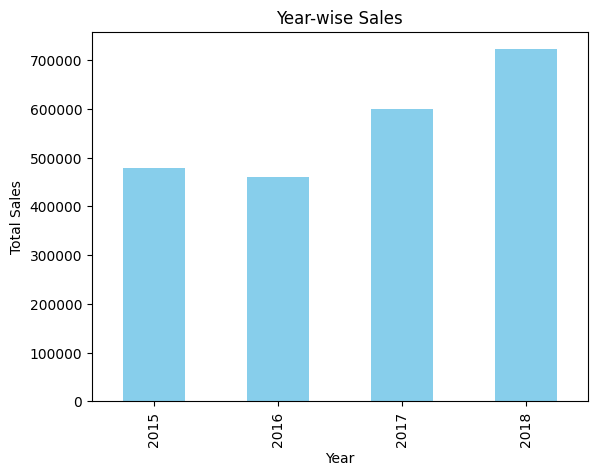

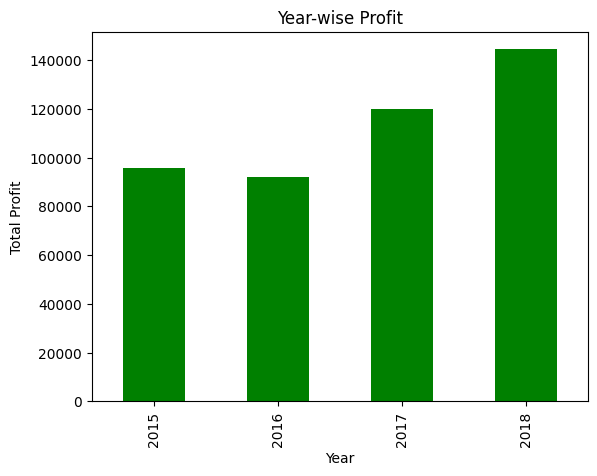

In [17]:
# Year-wise Sales and Profit Analysis

yearly_sales = df.groupby('Year')['Sales'].sum()
yearly_profit = df.groupby('Year')['Profit'].sum()

print("Year-wise Sales:")
print(yearly_sales)

print("\nYear-wise Profit:")
print(yearly_profit)

# Plot yearly sales
yearly_sales.plot(kind='bar', color='skyblue')
plt.title("Year-wise Sales")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()

# Plot yearly profit
yearly_profit.plot(kind='bar', color='green')
plt.title("Year-wise Profit")
plt.xlabel("Year")
plt.ylabel("Total Profit")
plt.show()

Data Visualization

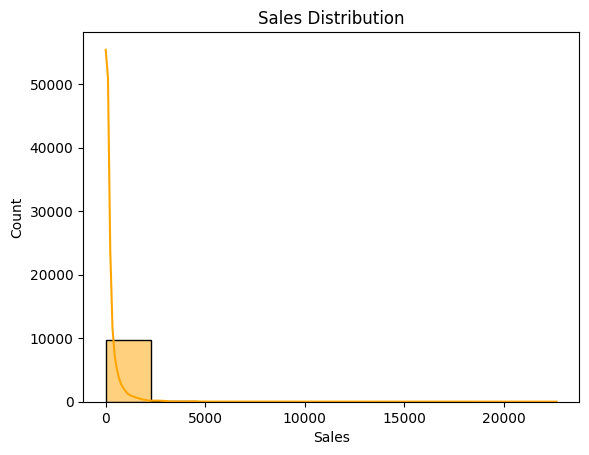

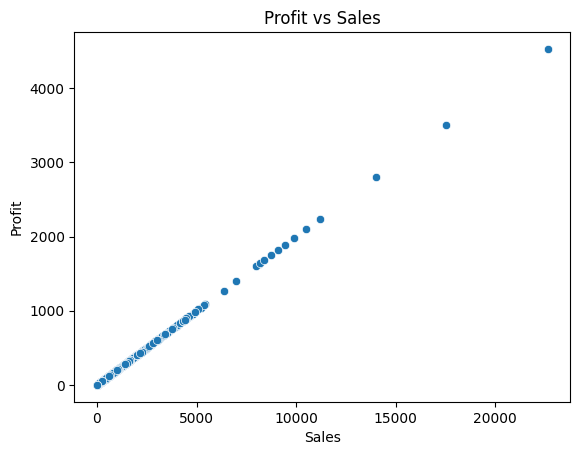

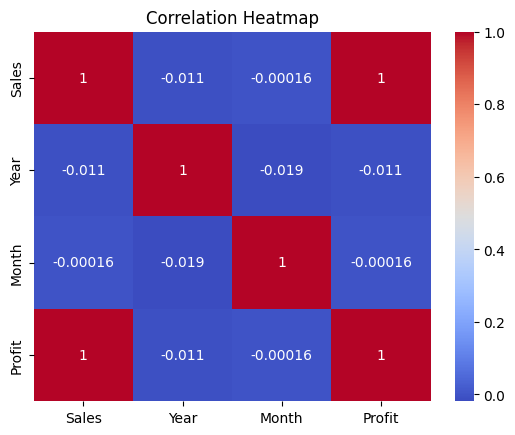

In [18]:
# Sales Distribution
sns.histplot(df['Sales'], bins=10, kde=True, color='orange')
plt.title('Sales Distribution')
plt.show()

# Profit vs Sales Scatter Plot
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title('Profit vs Sales')
plt.show()

# Heatmap of numeric correlations
numeric_cols = df.select_dtypes(include=np.number)
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# 12. Save Cleaned & Processed Dataset

In [19]:
df.to_csv("/content/processed_sales_data.csv", index=False)
from google.colab import files
files.download("/content/processed_sales_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dashboard of Analysis


In [20]:

import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# Load dataset (fixed file name)
data = pd.read_csv("/content/sales_dataset csv.csv")
data.columns = data.columns.str.strip()
# Convert to datetime
data["Order Date"] = pd.to_datetime(data["Order Date"], dayfirst=True)

# Create Month column (fixed issue)
data["Month"] = data["Order Date"].dt.strftime("%B")

# Create Profit/Loss status
data["Status"] = data["Profit"].apply(lambda x: "Profit" if x >= 0 else "Loss")

# Output widget
output = widgets.Output()

# ----------- FUNCTIONS -----------

def sales_summary(b):
    with output:
        clear_output()
        print(" SALES SUMMARY")
        print("Total Sales:", data["Sales"].sum())
        print("Average Sales:", data["Sales"].mean())
        print("Max Sales:", data["Sales"].max())
        print("Min Sales:", data["Sales"].min())

def profit_summary(b):
    with output:
        clear_output()
        print("PROFIT SUMMARY")
        print("Total Profit:", data["Profit"].sum())
        print("Average Profit:", data["Profit"].mean())
        print("Max Profit:", data["Profit"].max())
        print("Min Profit:", data["Profit"].min())

def profit_by_region(b):
    with output:
        clear_output()
        print(" PROFIT BY REGION")
        print(data.groupby("Region")["Profit"].sum())

def sales_by_region(b):
    with output:
        clear_output()
        print(" SALES BY REGION")
        print(data.groupby("Region")["Sales"].sum())

def profit_loss_status(b):
    with output:
        clear_output()
        print(" PROFIT vs LOSS")
        print(data["Status"].value_counts())

def monthly_sales(b):
    with output:
        clear_output()
        print("MONTHLY SALES TREND")
        monthly = data.groupby("Month")["Sales"].sum()
        print(monthly)

def show_table(b):
    with output:
        clear_output()
        print(" SAMPLE DATA")
        display(data.head(10))

# ----------- CHARTS -----------

def sales_chart(b):
    with output:
        clear_output()
        plt.figure()
        data.groupby("Region")["Sales"].sum().plot(kind='bar')
        plt.title("Sales by Region")
        plt.xlabel("Region")
        plt.ylabel("Sales")
        plt.xticks(rotation=45)
        plt.show()

def profit_chart(b):
    with output:
        clear_output()
        plt.figure()
        data.groupby("Region")["Profit"].sum().plot(kind='bar')
        plt.title("Profit by Region")
        plt.xlabel("Region")
        plt.ylabel("Profit")
        plt.xticks(rotation=45)
        plt.show()

def trend_chart(b):
    with output:
        clear_output()
        plt.figure()
        data.groupby("Month")["Sales"].sum().plot()
        plt.title("Sales Trend Over Months")
        plt.xlabel("Month")
        plt.ylabel("Sales")
        plt.xticks(rotation=45)
        plt.show()

# ----------- BUTTONS -----------

btn1 = widgets.Button(description="Sales Summary")
btn2 = widgets.Button(description="Profit Summary")
btn3 = widgets.Button(description="Profit by Region")
btn4 = widgets.Button(description="Sales by Region")
btn5 = widgets.Button(description="Profit vs Loss")
btn6 = widgets.Button(description="Monthly Sales")
btn7 = widgets.Button(description="Show Data")
btn8 = widgets.Button(description="Sales Chart")
btn9 = widgets.Button(description="Profit Chart")
btn10 = widgets.Button(description="Trend Chart")

# Attach functions
btn1.on_click(sales_summary)
btn2.on_click(profit_summary)
btn3.on_click(profit_by_region)
btn4.on_click(sales_by_region)
btn5.on_click(profit_loss_status)
btn6.on_click(monthly_sales)
btn7.on_click(show_table)
btn8.on_click(sales_chart)
btn9.on_click(profit_chart)
btn10.on_click(trend_chart)

# ----------- DISPLAY -----------

print(" SALES DASHBOARD WITH STATISTICAL ANALYSIS")

display(
    btn1, btn2, btn3, btn4, btn5,
    btn6, btn7, btn8, btn9, btn10,
    output
)


 SALES DASHBOARD WITH STATISTICAL ANALYSIS


Button(description='Sales Summary', style=ButtonStyle())

Button(description='Profit Summary', style=ButtonStyle())

Button(description='Profit by Region', style=ButtonStyle())

Button(description='Sales by Region', style=ButtonStyle())

...

Button(description='Show Data', style=ButtonStyle())

Button(description='Sales Chart', style=ButtonStyle())

Button(description='Profit Chart', style=ButtonStyle())

Button(description='Trend Chart', style=ButtonStyle())

Output()